In [1]:
import os

import torch
from torch import nn
from torch.utils.data import DataLoader

from src.utils.datasets import EmbeddingDataset
from src.utils.global_constants import MODELS_DIR
from src.utils.train_test import offline_train, mean_per_class_accuracy

# The random seed is fixed to ensure reproducibility of results
torch.manual_seed(42)
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)
device

device(type='cpu')

In [2]:
# Create a directory for trained models if it doesn't exist
os.makedirs(MODELS_DIR, exist_ok=True)

### Baseline MLP

In [3]:
class BaselineMLP(nn.Module):
    """Multi-Layer Perceptron model used as a reference for performance comparison

    This model is trained offline and serves as a baseline for evaluating the
    performance of proposed models trained in an online learning setting.
    """

    def __init__(
        self,
        input_dim: int = 2048,
        hidden_dim: int = 400,
        output_dim: int = 200,
        num_hidden_layers: int = 2,
    ):
        super().__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.classifier = nn.Sequential(*layers)

    def forward(self, x):
        return self.classifier(x)


mlp = BaselineMLP()

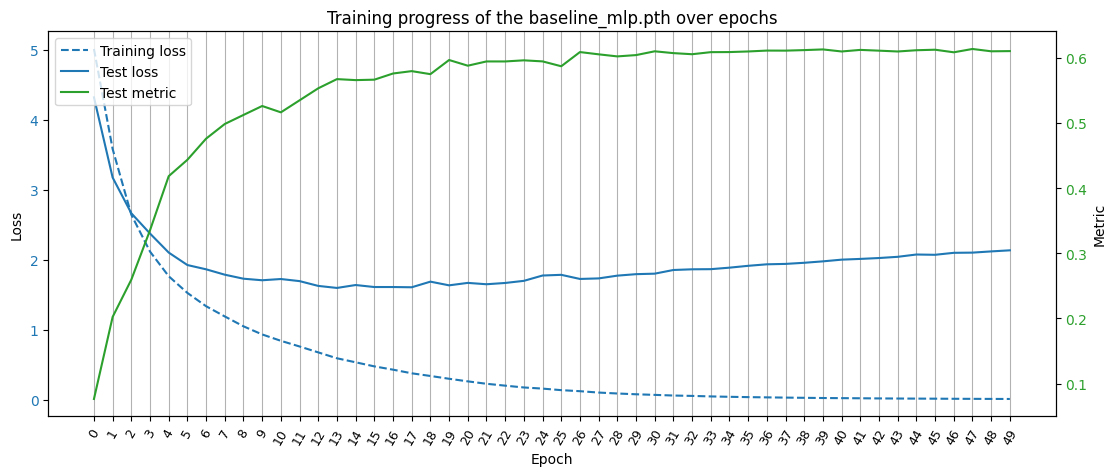

Early stopping is triggered at the epoch 49.
Best metric's value: 0.61308.
The model's weights are saved to /home/trxxxxkov/projects/spbu-bachelor-thesis/src/models/baseline_mlp.pth


In [4]:
# Training parameters for the baseline MLP model
mlp_batch_size = 256
mlp_learning_rate = 8e-4
mlp_num_epochs = 100
mlp_early_stopping_patience = 10
mlp_criterion = nn.CrossEntropyLoss()
mlp_optimizer = torch.optim.NAdam(mlp.parameters(), lr=mlp_learning_rate)
mlp_metric = mean_per_class_accuracy

# Loading training and testing datasets that contain precomputed elmbeddings
# generated by ResNet50 model
trainset = EmbeddingDataset("cub200_train_embed.pt")
testset = EmbeddingDataset("cub200_test_embed.pt")
trainloader = DataLoader(
    trainset, batch_size=mlp_batch_size, shuffle=True, num_workers=2
)
testloader = DataLoader(
    testset, batch_size=mlp_batch_size, shuffle=False, num_workers=2
)
# Perform offline training of the MLP baseline model with early stopping.
# This model is used in the continual learlning experiments described the thesis.
# The trained model's weights will be saved to the file `src/data/baseline_mlp.pth`.
offline_train(
    mlp,
    "baseline_mlp.pth",
    trainloader,
    testloader,
    mlp_criterion,
    mlp_metric,
    mlp_optimizer,
)

### Baseline KAN

In [5]:
class BaselineKAN(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        pass


kan = BaselineKAN()